# Lecture 9: Transfer learning

Link to Google Colab file: https://colab.research.google.com/drive/1nBDInqOUbyCt_tJE9A7EszCUpZ_jIMRc?usp=sharing 

## Overview

In this notebook, I use a pre-trained model, OMAR-RQ, to extract embeddings of the audio files in the MagnaTagATune dataset and perform genre classification using a 2-layer fully connected CNN on top to infer final predictions. I've also trained two transformer models on the original audio files to compare how much the evaluation metrics (ROC-AUC / PR-AUC) improve when using OMAR-RQ. 

OMAR-RQ is a model trained with self-supervision via masked token classification methodologies which was trained on a large-scale dataset with over 330,000 hours of music audio and achieved state-of-the-art performance in music tagging, pitch estimation, chord recognition, beat tracking, segmentation, and difficulty estimation among open self-supervised models. OMAR-RQ article was published [here](https://arxiv.org/pdf/2507.03482)

## Notebook Contents:
- **Step 1:** Load MagnaTagATune Dataset
- **Step 2:** Feature Extraction
- **Step 3:** Define the Transformer and MLP Architecture
- **Step 4:** Train and Evaluate the Models


In [1]:
# !pip install datasets[audio]==3
# !pip install matplotlib
# !pip install torch
# !pip install torchcodec
# !pip install tqdm
# !pip install transformers
# !pip install scikit-learn
# !pip install omar-rq

In [1]:

import math
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt

# AP - newly added imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torchaudio.transforms as T
import warnings


from datasets import load_dataset
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, f1_score
from sklearn.exceptions import UndefinedMetricWarning
from torch.utils.data import DataLoader, Dataset
from torchaudio.transforms import MelSpectrogram, Resample
from tqdm.auto import tqdm, trange
from omar_rq import get_model

device = "mps"  # Configure depending on the runtime

/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Step 1: Load MagnaTagATune Dataset

As in previous labs, I load the audio files and metadata. However, for this notebook I used the pre-trained model [OMAR-RQ](https://github.com/mtg/omar-rq) to extract embeddings on the audio files for the train, validation, and test datasets. 

We are using the base OMAR-RQ model configuration which has 12 layers and 512 embedding dimensions. These embeddings are calculated by OMAR-RQ based on it's pre-trained weights. The 512 embeddings are then averaged to form a tensor shaped as [Time Step, Average Embedding] and then squeezed to form a final embedding vector which takes into account sequential time step. 


In [2]:
# ==========================================================
# Load MagnaTagATune Annotations and Remove Corrupt Files
# ==========================================================

data_root = '../Lab 5'
mp3_root = '../Lab 5/mp3'

annotations = pd.read_csv(os.path.join(data_root, 'annotations_final.csv'), delimiter='\t')

# Identify empty MP3 files
empty_files = [
    file for file in annotations.mp3_path.values
    if file.lower().endswith('.mp3')
    and os.path.exists(os.path.join(mp3_root, file))
    and os.path.getsize(os.path.join(mp3_root, file)) == 0
]

print(f"Empty_files:\n{empty_files}")
print(len(annotations))

# Drop empty/corrupt files from the list of annotations
annotations = annotations[~annotations['mp3_path'].isin(empty_files)].reset_index(drop=True)

# Saving this version of annotations prior to genre filtering
all_annotations = annotations

print(len(annotations))

Empty_files:
['6/norine_braun-now_and_zen-08-gently-117-146.mp3', '8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3', '9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3']
25863
25860


In [3]:
# ==========================================================
# Filter Annotations for Only Relevant Genre Info
# ==========================================================

song_info = pd.read_csv(os.path.join(data_root, 'song_info.csv'), on_bad_lines='skip').fillna('')

# Splitting and cleaning genre information
def split_genres(col):
    genres = [g.strip().lower() for i in song_info[col].values for g in i.split(',') if g.strip()]
    return list(set(genres))

mp3_genre = split_genres('mp3genre')
magnatunegenres = split_genres('magnatunegenres')

# Aggregate a "complete" list of genres from both columns into a final list of all genres
all_genres =list(set(mp3_genre + magnatunegenres))

# Match the column names in Annotations_File.csv with the list of genres we've compiled above
annotations_labels = annotations.columns.values
genre_columns = [i for i in annotations_labels if i in all_genres]

# List of columns we will want to pull from the annotations_file.csv file
selected_columns = ['clip_id'] + genre_columns + ['mp3_path']
annotations = annotations[selected_columns]

# Remove rows that do not have any genre labels
annotations = annotations[~(annotations[genre_columns].sum(axis=1) == 0)]

annotations['track_folder'] = [i[0] for i in annotations['mp3_path'].str.split('/')]

# Print the removed columns to visually confirm they are not genre related
kept_columns = selected_columns + ['track_folder']
removed_columns = [col for col in all_annotations if col not in kept_columns]
print(f"Total original columns: {len(all_annotations)}")
print(f"Columns kept: {len(kept_columns)}")
print(f"Columns removed: {len(removed_columns)}")
print(f"\nRemoved columns:\n{removed_columns}")

Total original columns: 25860
Columns kept: 36
Columns removed: 155

Removed columns:
['no voice', 'singer', 'duet', 'plucking', 'bongos', 'female singing', 'clasical', 'sitar', 'chorus', 'female opera', 'male vocal', 'vocals', 'clarinet', 'heavy', 'silence', 'beats', 'men', 'woodwind', 'funky', 'no strings', 'chimes', 'foreign', 'no piano', 'horns', 'female', 'no voices', 'soft rock', 'eerie', 'spacey', 'quiet', 'no beat', 'banjo', 'electric', 'solo', 'violins', 'female voice', 'wind', 'happy', 'synth', 'no singing', 'middle eastern', 'trumpet', 'percussion', 'drum', 'airy', 'voice', 'repetitive', 'birds', 'space', 'strings', 'bass', 'harpsicord', 'male voice', 'girl', 'keyboard', 'acoustic', 'loud', 'classic', 'string', 'drums', 'electronic', 'not classical', 'chanting', 'no violin', 'not rock', 'no guitar', 'organ', 'no vocal', 'talking', 'weird', 'soprano', 'fast', 'acoustic guitar', 'electric guitar', 'male singer', 'man singing', 'classical guitar', 'violin', 'electro', 'tribal',

In [4]:
# ==========================================================
# Splitting Dataset Between Training / Validation / Testing
# ==========================================================

trainning_folders = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b' ]
val_folders = ['c']
test_folders = ['d','e','f']

train_split = annotations[annotations['track_folder'].isin(trainning_folders)]
val_split = annotations[annotations['track_folder'].isin(val_folders)]
test_split = annotations[annotations['track_folder'].isin(test_folders)]

In [5]:

# convert the train_split dataframe into a numpy array and pull only genre related columns (i.e. the labels)
y_train = train_split[train_split.columns[1:-2]].values
y_val = val_split[val_split.columns[1:-2]].values
y_test = test_split[test_split.columns[1:-2]].values

# convert the train_split dataframe into a numpy array and pull only metadata to identify the song (i.e. 'clip_id' and 'mp3_path')
X_train = train_split[[train_split.columns[0],train_split.columns[-2]]].values
X_val = val_split[[val_split.columns[0],val_split.columns[-2]]].values
X_test = test_split[[test_split.columns[0],test_split.columns[-2]]].values

print('X_train Shape:', X_train.shape)
print("y_train Shape:", y_train.shape)


X_train Shape: (13033, 2)
y_train Shape: (13033, 33)


In [6]:
# ================================
# Establishing Data Loading Class
# ================================

class MagnaTagATune(Dataset):
    def __init__(self, file_paths_and_ids, labels, target_duration=3.0, sample_rate=16000, transform=None, root_dir='./'):
        
        self.sample_rate = sample_rate # Standardized sample rate
        self.audio_duration = target_duration
        self.file_paths_and_ids = file_paths_and_ids # This contains the X_train/val/test ['clip_id', 'mp3_path'], ...]
        self.target_samples = max(int(target_duration * sample_rate), 1024)
        self.root_dir = root_dir
        self.transform = transform
        
        self.labels = {}
        self.audio_cache = {}       # < --- stores loaded audio here 

        # Debug: basic info
        print(f"\nInitializing MagnaTagATune dataset with {len(file_paths_and_ids)} files.")
        print(f"Sample rate: {self.sample_rate}, Target samples: {self.target_samples}")

        # match labels with clip id for easier debugging
        for idx, (clip_id, relative_path) in enumerate(file_paths_and_ids):
            if not relative_path.startswith('mp3/'):
                relative_path = os.path.join('mp3', relative_path)
                
            audio_path = os.path.join(root_dir, relative_path)    
            self.labels[idx] = torch.tensor(labels[idx], dtype=torch.float32)  # <-- use encoded

            try:
                audio, sr = torchaudio.load(audio_path)
            except Exception as e:
                
                # Return zero audio + zero lables to avoid breaking DataLoader
                print(f"Failed to load {audio_path}: {e}")
                audio = torch.zeros((1, self.target_samples))
                sr = self.sample_rate
                
            # If the original audio has a different sample rate, resample it
            if sr != self.sample_rate:
                audio = torchaudio.functional.resample(audio, sr, self.sample_rate)
             
            audio = self._crop_or_pad(audio)
            
            # Save audio tensor
            self.audio_cache[idx] = audio
        
        # make tids
        self.tids = list(self.audio_cache.keys())

    def __len__(self):
        return len(self.file_paths_and_ids)

    def _crop_or_pad(self, waveform):
        num_samples = waveform.shape[-1]
        if num_samples > self.target_samples:
            # Random crop during training, center crop for evaluation (though this dataset uses it for both)
            start = random.randint(0, num_samples - self.target_samples)
            waveform = waveform[:, start:start + self.target_samples]
        elif num_samples < self.target_samples:
            # Pad with zeros at the end
            pad_amount = self.target_samples - num_samples
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount))
        return waveform

    def __getitem__(self, idx):
        tid = self.tids[idx]
        audio = self.audio_cache[tid]
        label = self.labels[tid]
        
        
        if self.transform:
            audio = self.transform(audio)

        return {"audio": audio, "labels": label}


In [7]:
class MTATOMARRQDataset(Dataset):
    """OMAR-RQ embedding dataset based on GTZAN audio.
    """
    def __init__(self, audio_dataset, device):
        self.device =  device
        self.audio_dataset = audio_dataset

        self.labels = self.audio_dataset.labels
        self.tids = self.audio_dataset.tids
        
        # Instantiate OMAR-RQ model
        self.model = get_model(model_id="mtg-upf/clap_omarrq_mp_small_music", device=self.device)
        self.model.eval()

        # Select intermediate layer
        self.layers = [6]

        # Load audio and labels
        self.embeddings = {}
        for id, audio in tqdm(self.audio_dataset.audio_cache.items(), desc="Computing embeddings"):

            audio = torch.tensor(audio, dtype=torch.float32)
            
            audio = audio.to(self.device)

            with torch.no_grad():
              embeddings = self.model.extract_embeddings(audio, layers=self.layers)

            embeddings = torch.mean(embeddings, dim=2)
            embeddings = embeddings.squeeze()

            self.embeddings[id] = embeddings
  
    def __len__(self):
        return len(self.tids)


    def __getitem__(self, idx):
        tid = self.tids[idx]
        embeddings = self.embeddings[tid]
        labels = self.labels[tid]

        return {"embeddings": embeddings, "labels": labels}
      


In [8]:
# ==================================
# Implement Loading Data Functions
# ==================================

batch_size = 32 
target_duration = 3.0
sample_rate = 16000

train_transforms=None
val_transforms=None

# Instantiate the dataset using the corrected class
train_audio_dataset = MagnaTagATune(X_train, y_train, target_duration=target_duration, transform=train_transforms, root_dir=data_root)
val_audio_dataset = MagnaTagATune(X_val, y_val,target_duration=target_duration, transform=val_transforms,root_dir=data_root)
test_audio_dataset = MagnaTagATune(X_test, y_test,target_duration=target_duration, transform=val_transforms,root_dir=data_root)




Initializing MagnaTagATune dataset with 13033 files.
Sample rate: 16000, Target samples: 48000

Initializing MagnaTagATune dataset with 1337 files.
Sample rate: 16000, Target samples: 48000

Initializing MagnaTagATune dataset with 3693 files.
Sample rate: 16000, Target samples: 48000


In [9]:
# ==================================
# Extract Embeddings from Data
# ==================================

train_dataset = MTATOMARRQDataset(train_audio_dataset, device=device)
val_dataset = MTATOMARRQDataset(val_audio_dataset, device=device)
test_dataset = MTATOMARRQDataset(test_audio_dataset, device=device)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=False)



OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`


Computing embeddings:   0%|          | 0/13033 [00:00<?, ?it/s]/var/folders/r4/z65_5ryn59z3_3lyzgvxdcm40000gn/T/ipykernel_14361/2673358152.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  audio = torch.tensor(audio, dtype=torch.float32)
Computing embeddings: 100%|██████████| 13033/13033 [02:31<00:00, 85.98it/s]


OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`


Computing embeddings: 100%|██████████| 1337/1337 [00:15<00:00, 87.70it/s]


OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`


Computing embeddings: 100%|██████████| 3693/3693 [00:41<00:00, 89.09it/s]


In [10]:
print("train_dataset:", len(train_dataset))
print("val_dataset:", len(val_dataset))
print("test_dataset:", len(test_dataset))

print("val_audio_dataset.audio_cache:", len(val_audio_dataset.audio_cache))

print("val_embeddings stored:", len(val_dataset.embeddings))
print("val_audio_tids:", len(val_audio_dataset.tids))
print("val_tids:", len(val_dataset.tids))

print("val_dataset.embeddings.keys:", list(val_dataset.embeddings.keys())[:5])
print("val_dataset.tids:", val_dataset.tids[:5])

for tid, audio in list(train_audio_dataset.audio_cache.items())[:1]:
    print("raw audio shape:", audio.shape)



train_dataset: 13033
val_dataset: 1337
test_dataset: 3693
val_audio_dataset.audio_cache: 1337
val_embeddings stored: 1337
val_audio_tids: 1337
val_tids: 1337
val_dataset.embeddings.keys: [0, 1, 2, 3, 4]
val_dataset.tids: [0, 1, 2, 3, 4]
raw audio shape: torch.Size([1, 48000])


In [11]:
print("val_audio_tids:", val_audio_dataset.tids)
print("val_tids:", val_dataset.tids)

val_audio_tids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218

# Step 2: Feature Extraction

Mel-spectrograms were extracted as before. I made small adjustments to ensure all operations run on the correct device (CPU vs MPS/GPU), but the overall feature extraction pipeline remains the same.

In [12]:
class FeatureExtractor(nn.Module):
    """Log mel-spectrogram feature extractor.
    """

    def __init__(self, **kwargs):
        super().__init__()
        self.melspectrogram = MelSpectrogram(**kwargs)

    def to(self, device):
        # Move entire module
        super().to(device)

        # Move torchaudio internal buffers (very important!)
        for name, buf in self.melspectrogram.named_buffers():
            if buf is not None:
                setattr(self.melspectrogram, name, buf.to(device))

            return self

    def forward(self, x):
        if x.ndim == 3 and x.shape[1] == 1:  # (batch, 1, time)
            x = x.squeeze(1)                 # -> (batch, time)
        x = self.melspectrogram(x)

        # Log-compression
        x = torch.log10(1 + 1000 * x)
        return x

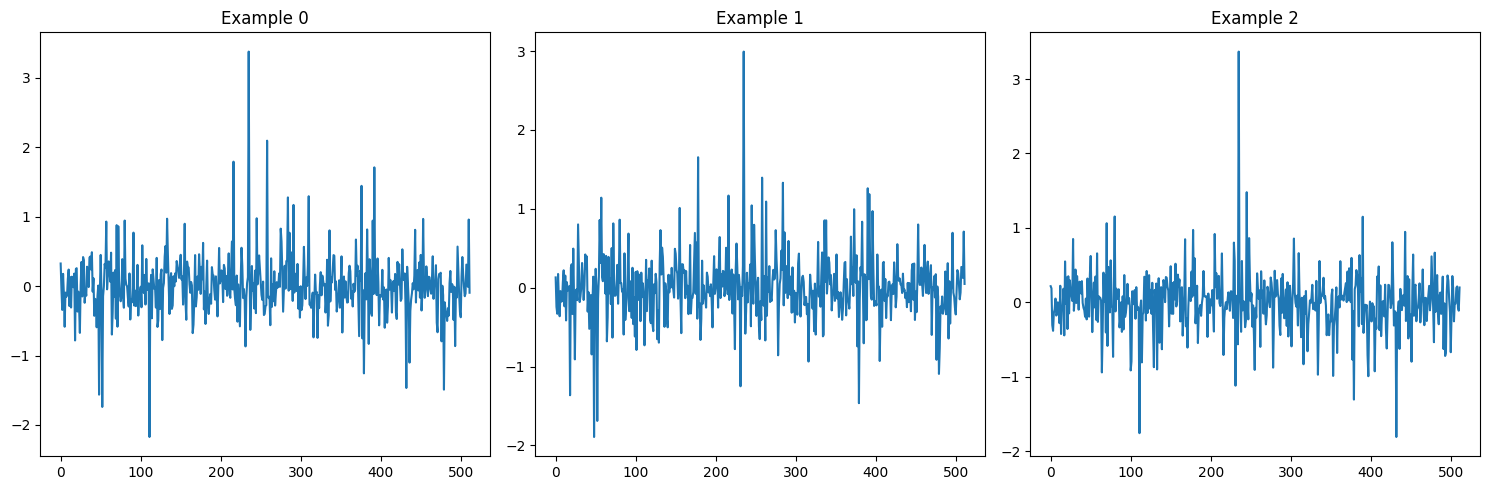

In [13]:
# ==================================
# Plotting Embedding Examples
# ==================================

# Fetch a batch of data
batch = next(iter(val_loader))
embeddings = batch["embeddings"].cpu().numpy()

# Visualize the first three mel-spectrograms in the batch
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].plot(embeddings[i])
    axes[i].set_title(f"Example {i}")

plt.tight_layout()
plt.show()

In [14]:
n_classes = len(list(val_dataset.labels.values())[0])

print("Embeddings shape:", embeddings.shape)
print("Number of classes:", n_classes)

Embeddings shape: (32, 512)
Number of classes: 33


# Step 3: Define the Transformer and MLP Architecture

The baseline transformer includes patch extraction, positional encoding, a CLS token and a standard TransformerEncoder stack.

The baseline MLP includes 2 linear fully connected layers with dense size 64 and relu activation function to introduce non-linearity. 

In [15]:
class Transformer(nn.Module):
    """Transformer model for audio classification.

    Args:
        kernel (tuple, optional): Kernel size for the convolutional patch embedding. Defaults to (8, 8).
        stride (tuple, optional): Stride for the convolutional patch embedding. Defaults to (8, 8).
        n_blocks (int, optional): Number of Transformer encoder blocks. Defaults to 2.
        emb_dim (int, optional): Embedding dimension. Defaults to 128.
        n_heads (int, optional): Number of attention heads. Defaults to 2.
        mlp_ratio (int, optional): Ratio of MLP hidden dimension to embedding dimension. Defaults to 2.
        output_size (int, optional): Number of output classes. Defaults to 10.
    """

    def __init__(
        self,
        kernel: tuple = (8, 8),
        stride: tuple = (8, 8),
        n_blocks: int = 2,
        emb_dim: int = 128,
        n_heads: int = 2,
        mlp_ratio: int = 2,
        output_size: int = n_classes, # changed to match n_classes
        pos_enc_gain: float = 0.0,
        cls_token_ratio: float = 0.0,
    ):
        super().__init__()

        self.n_blocks = n_blocks
        self.emb_dim = emb_dim
        self.n_heads = n_heads
        self.mlp_ratio = mlp_ratio
        self.output_size = output_size
        self.pos_enc_gain = pos_enc_gain
        self.cls_token_ratio = cls_token_ratio

        self.norm = nn.BatchNorm2d(1)

        padding = kernel[0] // 2
        self.patching = nn.Conv2d(
            1, self.emb_dim, kernel_size=kernel, stride=stride, padding=padding
        )

        self.blocks = nn.ModuleList([
          nn.TransformerEncoderLayer(
              self.emb_dim,
              self.n_heads,
              dim_feedforward=self.emb_dim * self.mlp_ratio,
              dropout=0.1,
              norm_first=True,
          ) for _ in range(self.n_blocks)])

        self.cls = nn.Parameter(torch.randn(1, 1, self.emb_dim))

        nn.init.normal_(self.cls, std=0.02)

        self.fc1 = nn.Linear(self.emb_dim, self.emb_dim)
        self.fc2 = nn.Linear(self.emb_dim, self.output_size)

    def positional_encoding(self, seq_len):
        position = torch.arange(seq_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, self.emb_dim, 2, dtype=torch.float32) * -(math.log(10000.0) / self.emb_dim))

        pe = torch.zeros(seq_len, self.emb_dim, device=self.cls.device)

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe

    def forward(self, x):
        # Add embedding dimension
        x = x.unsqueeze(1)

        # Normalize input to zero-mean unit std.
        x = self.norm(x)

        # Divide the signal into patches
        x = self.patching(x)  # [B, 1, freq, time] -> [b, E, M, T]

        B, E, M, T = x.shape

        # Generate positional encodings for frequency and time
        pe_m = self.positional_encoding(M) # (M, E)
        pe_t = self.positional_encoding(T) # (T, E)

        pe_m_reshaped = pe_m.transpose(0, 1).unsqueeze(0).unsqueeze(3) # (1, E, F, 1)
        pe_t_reshaped = pe_t.transpose(0, 1).unsqueeze(0).unsqueeze(2) # (1, E, 1, T)

        # Add positional encoding with small gain.
        x = x + self.pos_enc_gain * (pe_m_reshaped + pe_t_reshaped)

        x = x.flatten(start_dim=2)  # [B, E, F, T] -> [B, E, F * T]
        x = x.swapaxes(1, 2)  # [B, E, F * T] -> [B, F * T, E]

        # Concatenate CLS token
        cls = self.cls.repeat(B, 1, 1)
        x = torch.cat([cls, x], dim=1)

        # Transformer backbone
        for block in self.blocks:
          x = block(x)

        # Classification on top of the CLS + average of the rest of tokens
        x_cls = x[:, 0, :]
        x_mean = x[:, 1:, :].mean(dim=1)
        x = self.cls_token_ratio * x_cls + (1 - self.cls_token_ratio) * x_mean

        # Dense classification head
        x = F.layer_norm(x, (self.emb_dim,))
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [16]:
class MLP(nn.Module):
    def __init__(
        self,
        input_size: int=512,
        dense_size: int=64,
        output_size: int=n_classes,  # changed to 33 for the number of genres
    ):
        super().__init__()
        self.input_size = input_size
        self.dense_size = dense_size
        self.output_size = output_size

        self.fc1 = nn.Linear(self.input_size, self.dense_size)
        self.fc2 = nn.Linear(self.dense_size, self.output_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Step 4: Train and Evaluate the Models

Similar to previous labs, I replaced the cross-entropy loss function with `BCEWithLogitsLoss` since MagnaTagATune is a multi-label dataset, and evaluated model performance based on with ROC-AUC and PR-AUC values. 

In the graphs below, we can see that even after reducing the number of epochs from 100 to 50, the models start to overfit the training data as validation metrics (accuracy / loss) plateau and training metrics improve. 

## Results
------ 
Similar to previous labs, I chose to use macro **ROC-AUC** and **PR-AUC** metrics to evaluate model performance since these metrics treat each tag equally regardless of frequency. 

| Model                             | Test loss | Test Acc  | ROC-AUC   | PR-AUC    | 
| --------------------------------- | --------- | --------- | --------- | --------- | 
| **Transformer Baseline**          | 0.109     | 0.448     | 0.880     | 0.283     |
| **Transformer w/ CLS + Pos_Enc**| 0.103     | 0.438     | 0.885     | 0.299     | 
| **OMAR-RQ + MLP**                 | **0.102** | **0.505**     | **0.893** | **0.325** | 

As expected, the **OMAR-RQ + MLP** model surpasses both Transformer baselines on all major evaluation metrics. This aligns with prior findings showing OMAR-RQ as state-of-the-art in music tagging and audio representation learning. Its masked-token reconstruction objective allows it to extract semantically meaningful audio features that generalize far beyond the training set, unlike smaller Transformers that must learn everything from scratch on a limited dataset. 


## Interpretation:
------ 
### **Transformer Baseline:** 
Performed the worst as expected since audio patches without positional context force the model to treat all patches as exchangable. Positional information is crucial for genre classification since temporal features like rhythm, chord changes, and timbral evolution are inherently sequential, so losing positional information reduces structure and harms performance. This causes the model to overfit instead of capturing robust musical traits.  

### **Transformer w/ CLS + Pos_Enc:** 
All metrics except test accuracy improved in this model compared to the baseline Transformer, proving as seen in the previous lab that the addition of patch overlap, CLS tokens, and positional encoding help the transformer to generalize the audio features related to genre classification. 

### **OMAR-RQ + MLP:** 
Scored the highest across all metrics. The OMAR-RQ encoder paired with a simple MLP head achieves the best results because it was pre-trained on a much larger corpus of data (+330,000 hours), is trained based on multiple audio features, and employs masked token prediction. 

**Multi-Feature Approach Includes:**
- **MelSpectrogram** - a time-frequency visual representation of sound using the Mel-scaled frequencies that mirror human hearing
- **Waveform** - raw visual plot of a sound's amplitude over time, fundamental to undersatnd loudness and basic structure
- **CQT (Constant-Q Transform)**: a time-frequency analysis tool that provides logarithmic frequency resolution, perfectly aligning with musical scales by using varying window sizes for different frequencies
- **EnCodec**: an internal latent representation produced by a high-fidelity neural audio codec developed by Défossez et al. (Meta AI, 2022). This encoder is optimized to preserve perceptually important aspects of sound and provide a more robust representation of the audio as they are learned via a reconstruction objective. 

The combination of these audio features helps the model encode a more diverse set of features whereas the Transformer model was only trained based on MelSpectrograms of the audio. 

**Masked Token Prediction:**
The model is trained to reconstruct masked regions of the inputted training audio using the surrounding context, forcing the model to learn the overall structure of the inputted audio, local cues, and becomes noise-tolerant. 

## Conclusion
------ 
The OMAR-RQ + MLP architecture demonstrates a clear advantage over both Transformer models, consistent with prior literature establishing OMAR-RQ as state of the art for music representation learning. By incorporating the masked token prediction, multi-feature dataset, and exposure to over 330,000 of diverse audio training data, the model can extract highly generalizable features that encode timbre, harmony, rhythm, and long-form musical structure. This leads to substantial improvements in ranking-based metrics (ROC-AUC) and rare-label retrieval (PR-AUC), confirming that large-scale self-supervision offers significant benefits for downstream genre classification tasks.





In [17]:

def step(batch, loss_fn, model, device=device, optimizer=None, mode="audio", return_logits=False):
    y = batch["labels"].to(device)

    if mode == "audio":
        x = batch["audio"].to(device)
        x = feature_extractor(x)
    elif mode == "embeddings":
        x = batch["embeddings"]

    # Forward
    y_est = model(x)

    # Compute loss
    loss = loss_fn(y_est, y)
    step_loss = loss.item()

    # Compute metrics
    y_est = y_est.softmax(dim=1)
    y_int = torch.argmax(y, dim=1).cpu().numpy()
    y_est_int = torch.argmax(y_est, dim=1).cpu().numpy()

    step_acc = accuracy_score(y_int, y_est_int)

    # Backprop
    if optimizer:
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # return logits (y_est) and labels (y) if requested 
    if return_logits:
        return step_loss, step_acc, y_est.detach(), y.detach()

    return step_loss, step_acc

def train(
    model,
    train_dataset,
    val_dataset,
    n_epochs=3,
    lr=0.001,
    device="mps",
    batch_size=32,
    mode="audio",
):
    # Use Adam optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # changed the loss function here to be compatible with multi-label dataset
    loss_fn = torch.nn.BCEWithLogitsLoss()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # ---- History for visualization ----
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    # pbar = trange(n_epochs, desc="Training", total=n_epochs)
    for epoch in range(n_epochs):
        # Training loop

        model.train()
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
        
        total_loss, total_acc = 0, 0

        for batch in pbar:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                warnings.simplefilter("ignore", category=UndefinedMetricWarning)
                
                step_loss, step_acc = step(
                    batch, 
                    loss_fn, 
                    model, 
                    device, 
                    optimizer, 
                    mode=mode, 
                    return_logits=False
                    )
                
                total_loss += step_loss
                total_acc += step_acc

                pbar.set_postfix({
                        "loss": f"{step_loss:.4f}",
                    })

        train_loss = total_loss / len(train_loader)
        train_acc = total_acc / len(train_loader)

        # Validation loop
        model.eval()
        total_loss, total_acc = 0, 0

        with torch.no_grad():
            for batch in val_loader:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=UserWarning)
                    warnings.simplefilter("ignore", category=UndefinedMetricWarning)
                
                    step_loss, step_acc = step(
                        batch, 
                        loss_fn, 
                        model, 
                        device,
                        mode=mode
                        )
                
                total_loss += step_loss
                total_acc += step_acc
                
        val_loss = total_loss / len(val_loader)
        val_acc = total_acc / len(val_loader)

        # Store history
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        pbar.set_postfix({
            # "epoch": f"{epoch+1}",
            "train loss": f"{train_loss:.3f}",
            "train acc": f"{train_acc:.3f}",
            "val loss": f"{val_loss:.3f}",
            "val acc": f"{val_acc:.3f}",
        })
        
    # ----- Visualization -----
    plt.figure(figsize=(12,4))

    # Validation Loss
    plt.subplot(1,2,1)
    plt.plot(history["val_loss"], label="Val Loss")
    plt.plot(history["train_loss"], label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Loss Curve")
    plt.grid(True)
    plt.legend()

    # Validation Accuracy
    plt.subplot(1,2,2)
    plt.plot(history["val_acc"], label="Val Accuracy")
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy Curve")
    plt.grid(True)
    plt.legend()

    plt.show()

    return history


def test(model, dataset, device="mps", batch_size=32, mode="audio"):
    # Test loop
    test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # changed the loss function here to be compatible with a multi-label dataset
    loss_fn = torch.nn.BCEWithLogitsLoss()

    model.eval()
    total_loss, total_acc = 0, 0
    
    all_logits = []
    all_targets = []


    for batch in test_loader:
        step_loss, step_acc, logits, targets = step(batch, loss_fn, model, mode=mode, return_logits=True)
        total_loss += step_loss
        total_acc += step_acc
        
        all_logits.append(logits.cpu())
        all_targets.append(targets.cpu())

    # Concatenate all batches
    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    # Convert logits -> probabilities
    all_probs = torch.sigmoid(all_logits).numpy()
    all_targets_np = all_targets.numpy()

    # ----- Multi-label Metrics -----
    try:
        roc_auc = roc_auc_score(all_targets_np, all_probs, average="macro")
    except ValueError:
        roc_auc = float("nan")  # happens if a label has only one class present

    try:
        pr_auc = average_precision_score(all_targets_np, all_probs, average="macro")
    except ValueError:
        pr_auc = float("nan")

    
    # Standard test metrics
    test_loss = total_loss / len(test_loader)
    test_acc = total_acc / len(test_loader)

    print(
        f"test loss: {test_loss:.3f}, "
        f"test acc: {test_acc:.3f}"
        f"ROC-AUC (macro): {roc_auc:.3f}, "
        f"PR-AUC (macro): {pr_auc:.3f}"
    )

Training Transformer encoder
Number of trainable parameters: 77475


Epoch 50/50: 100%|██████████| 408/408 [00:28<00:00, 14.09it/s, loss=0.0903]


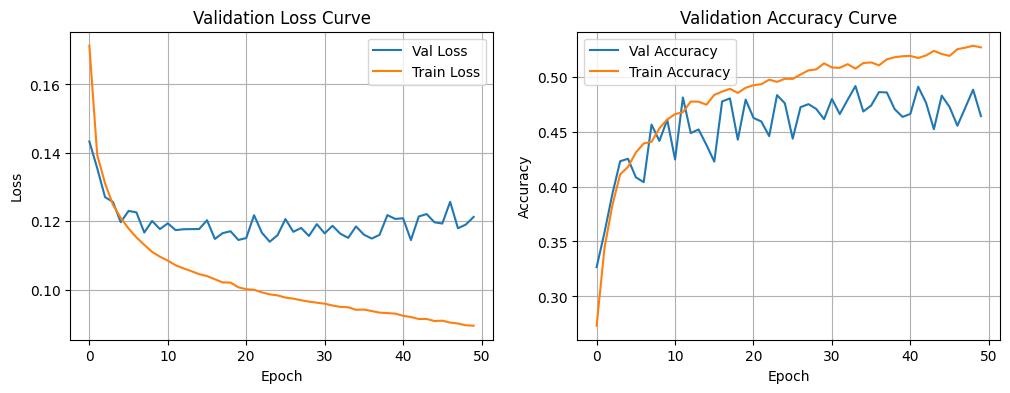

In [54]:
feature_extractor = FeatureExtractor(n_mels=64, n_fft=1024).to(device)

model_tr = Transformer(
    n_blocks=2,
    emb_dim=64,
    n_heads=4,
).to(device)

print("Training Transformer encoder")

num_params = sum(p.numel() for p in model_tr.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")


history = train(model_tr, train_audio_dataset, val_audio_dataset, n_epochs=50, device=device, batch_size=32, mode="audio")

print("\n")


In [55]:
test(model_tr, test_audio_dataset, mode="audio")

/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")


test loss: 0.109, test acc: 0.448ROC-AUC (macro): 0.880, PR-AUC (macro): 0.283



Training CNN encoder
MLP Trainable parameters: 34977


Epoch 50/50: 100%|██████████| 408/408 [00:00<00:00, 477.03it/s, loss=0.0455]


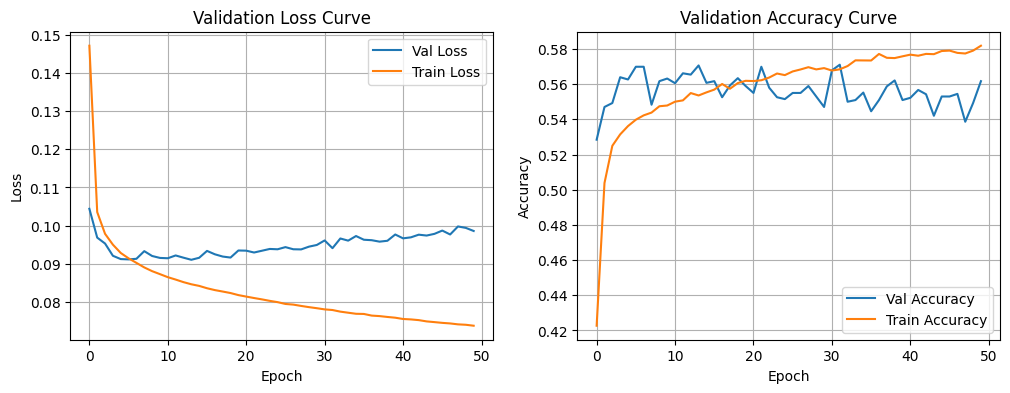

{'train_loss': [0.1471966531346826,
  0.10352295839830357,
  0.09781675718213413,
  0.09497281122843132,
  0.09279317028966605,
  0.09138177251260654,
  0.09019287873753438,
  0.08899741960397246,
  0.08801772582399495,
  0.08723298683945163,
  0.08643952973515671,
  0.08580939115627724,
  0.08513496512108866,
  0.084573031859655,
  0.08414725539292775,
  0.08353283598690349,
  0.08304483125753262,
  0.08266573235867362,
  0.0822708056783121,
  0.08173208823427558,
  0.08134115396030978,
  0.0809619272967764,
  0.08060687635203495,
  0.08022097358480096,
  0.07988269387872196,
  0.07940591849824961,
  0.07923707921130985,
  0.07888854080445919,
  0.07857141311408258,
  0.07829038300277556,
  0.07798204429484173,
  0.0778142070105555,
  0.07738994142296267,
  0.07710724825258641,
  0.07682700673410413,
  0.0767815615799205,
  0.07635048852649097,
  0.07621905390246242,
  0.07599393576018366,
  0.07579686328330461,
  0.07546055165356864,
  0.07534859051891402,
  0.07516167682650335,
  0.

In [52]:
model_mlp = MLP().to(device)

print("\nTraining CNN encoder")

num_params = sum(p.numel() for p in model_mlp.parameters() if p.requires_grad)
print(f"MLP Trainable parameters: {num_params}")

train(model_mlp, train_dataset, val_dataset, n_epochs=50, device=device, batch_size=32, mode="embeddings")


In [53]:
test(model_mlp, test_dataset, mode="embeddings")

/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/Users/arianapereira/Documents/Masters/ClassWork/Machine_Learning/.venvpy311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem,

test loss: 0.102, test acc: 0.505ROC-AUC (macro): 0.893, PR-AUC (macro): 0.325


Training Transformer encoder
Number of trainable parameters: 77475


Epoch 50/50: 100%|██████████| 408/408 [00:33<00:00, 12.18it/s, loss=0.0650]


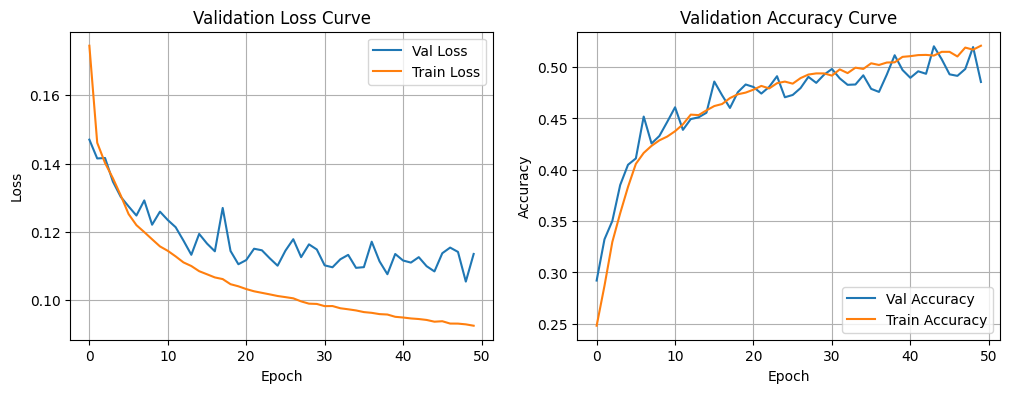

In [18]:
feature_extractor = FeatureExtractor(n_mels=64, n_fft=1024).to(device)

model_tr_2 = Transformer(
    n_blocks=2,
    emb_dim=64,
    n_heads=4,
    stride=(4,4),
    pos_enc_gain=0.5,
    cls_token_ratio=0.25,
).to(device)

print("Training Transformer encoder")

num_params = sum(p.numel() for p in model_tr_2.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")


history = train(model_tr_2, train_audio_dataset, val_audio_dataset, n_epochs=50, device=device, batch_size=32, mode="audio")

print("\n")

In [ ]:
test(model_tr_2, test_audio_dataset, mode="audio")